In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb

In [2]:
df = pd.read_csv("data/final_dataset.csv")

In [3]:
df.head()

,Date,corruption,bribe,verdict,embezzlement,investigation,detention,dollar,million,billion,...,court,ministry,akim,chief,deputy,district,city,region,offense,Total Crimes
0,2016-11,54,76.0,6.0,10.0,15.0,20.0,16.0,35.0,6.0,...,28.0,20.0,1.0,4.0,17.0,6.0,5.0,32.0,7.0,3463.0
1,2016-12,40,24.0,2.0,4.0,11.0,7.0,3.0,15.0,1.0,...,16.0,13.0,6.0,3.0,9.0,4.0,3.0,14.0,6.0,3214.0
2,2017-01,41,29.0,1.0,1.0,14.0,16.0,4.0,13.0,7.0,...,26.0,8.0,9.0,5.0,16.0,13.0,3.0,14.0,2.0,1137.0
3,2017-02,24,16.0,15.0,19.0,16.0,10.0,18.0,40.0,11.0,...,43.0,8.0,3.0,5.0,3.0,3.0,9.0,14.0,3.0,1337.0
4,2017-03,33,26.0,10.0,24.0,26.0,8.0,8.0,45.0,12.0,...,62.0,25.0,12.0,2.0,18.0,17.0,12.0,23.0,7.0,1566.0


In [4]:
df["Date"] = pd.to_datetime(df["Date"])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           99 non-null     datetime64[ns]
 1   corruption     99 non-null     int64         
 2   bribe          99 non-null     float64       
 3   verdict        99 non-null     float64       
 4   embezzlement   99 non-null     float64       
 5   investigation  99 non-null     float64       
 6   detention      99 non-null     float64       
 7   dollar         99 non-null     float64       
 8   million        99 non-null     float64       
 9   billion        99 non-null     float64       
 10  agency         99 non-null     float64       
 11  crime          99 non-null     float64       
 12  court          99 non-null     float64       
 13  ministry       99 non-null     float64       
 14  akim           99 non-null     float64       
 15  chief          99 non-nul

In [6]:
df.head()

,Date,corruption,bribe,verdict,embezzlement,investigation,detention,dollar,million,billion,...,court,ministry,akim,chief,deputy,district,city,region,offense,Total Crimes
0,2016-11-01,54,76.0,6.0,10.0,15.0,20.0,16.0,35.0,6.0,...,28.0,20.0,1.0,4.0,17.0,6.0,5.0,32.0,7.0,3463.0
1,2016-12-01,40,24.0,2.0,4.0,11.0,7.0,3.0,15.0,1.0,...,16.0,13.0,6.0,3.0,9.0,4.0,3.0,14.0,6.0,3214.0
2,2017-01-01,41,29.0,1.0,1.0,14.0,16.0,4.0,13.0,7.0,...,26.0,8.0,9.0,5.0,16.0,13.0,3.0,14.0,2.0,1137.0
3,2017-02-01,24,16.0,15.0,19.0,16.0,10.0,18.0,40.0,11.0,...,43.0,8.0,3.0,5.0,3.0,3.0,9.0,14.0,3.0,1337.0
4,2017-03-01,33,26.0,10.0,24.0,26.0,8.0,8.0,45.0,12.0,...,62.0,25.0,12.0,2.0,18.0,17.0,12.0,23.0,7.0,1566.0


Correlation with the target variable:
Total Crimes     1.000000
dollar           0.265334
corruption       0.194084
crime            0.191749
bribe            0.174378
investigation    0.172849
agency           0.151473
ministry         0.148085
region           0.132093
detention        0.123826
district         0.121275
city             0.108854
million          0.108031
akim             0.101624
deputy           0.094644
verdict          0.077149
chief            0.045715
court            0.032344
offense          0.031368
embezzlement     0.013643
billion         -0.084033
Date            -0.413425
Name: Total Crimes, dtype: float64


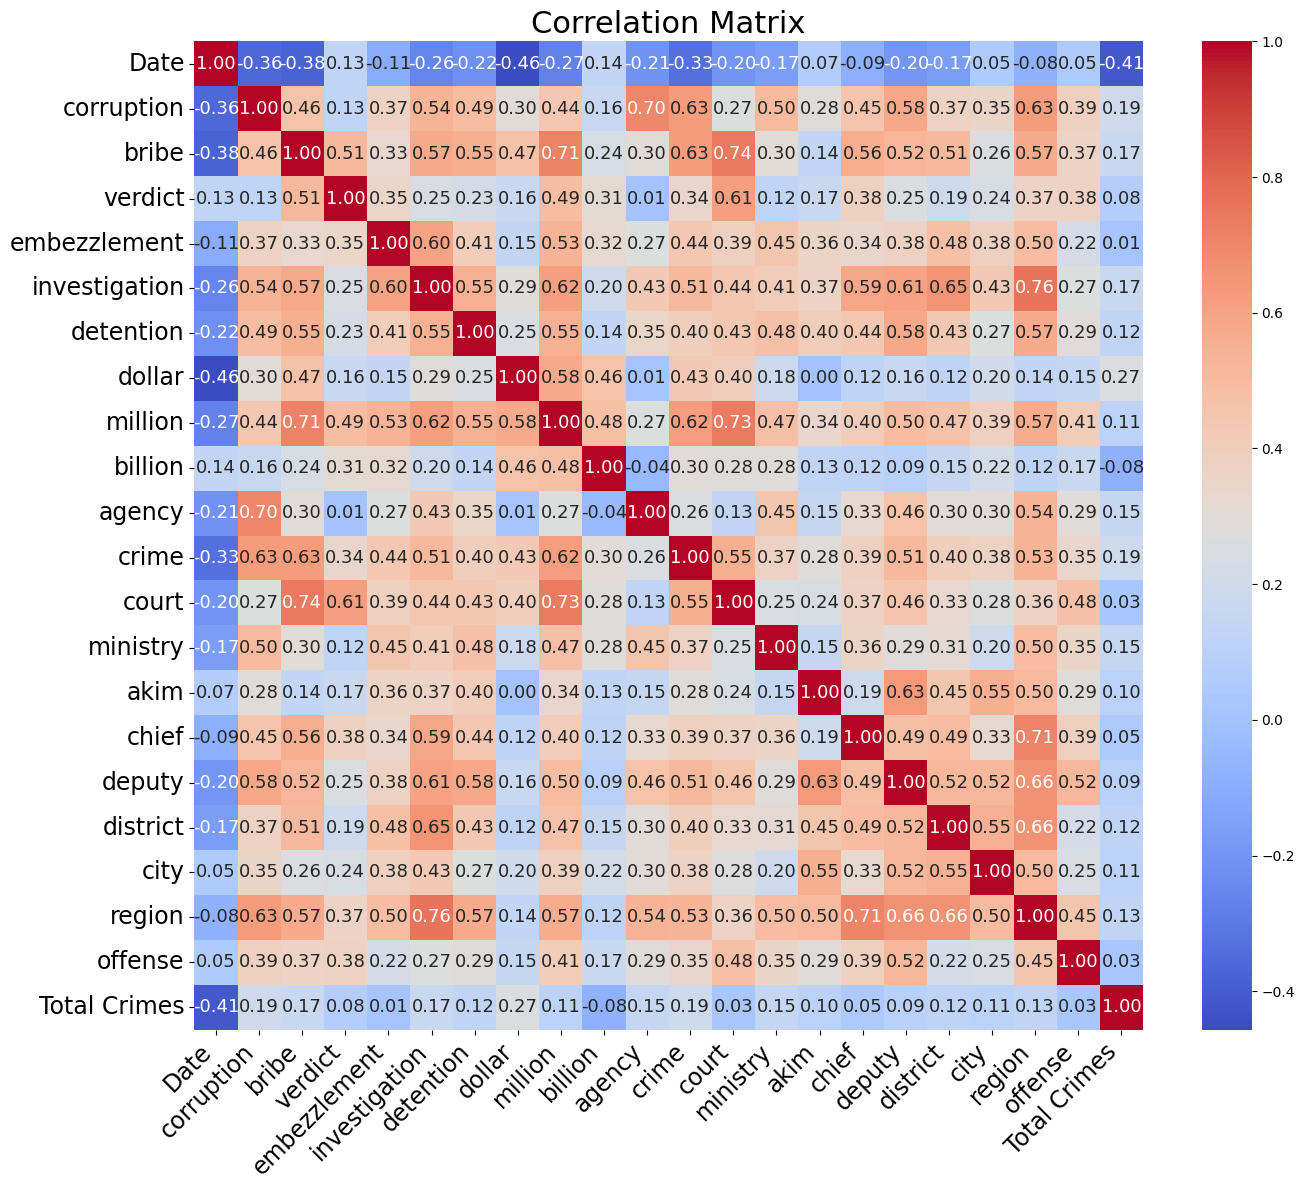

In [7]:
# Corr matrix plot settings
title_size = 22
labels_size = 17
legend_size = 17


# Calculate correlation
correlation_matrix = df.corr()

# Display correlation of the target variable with other features
target_corr = correlation_matrix["Total Crimes"].sort_values(ascending=False)
print("Correlation with the target variable:")
print(target_corr)

# Visualize the correlation matrix with larger labels and title
plt.figure(figsize=(14, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    annot_kws={"size": 13},
    xticklabels=correlation_matrix.columns,
    yticklabels=correlation_matrix.columns
)

plt.title("Correlation Matrix", fontsize=title_size)
plt.xticks(fontsize=labels_size, rotation=45, ha='right')
plt.yticks(fontsize=labels_size)
plt.tight_layout()
plt.show()

In [8]:
# Create a new dataframe with aggregated features
df_agg = pd.DataFrame()

# Aggregated features
df_agg['Corruption_Sum'] = df[['corruption', 'bribe', 'verdict', 'embezzlement', 'investigation']].sum(axis=1)
df_agg['Detentions_Sum'] = df[['detention']].sum(axis=1)
df_agg['Finance_Sum'] = df[['dollar', 'million', 'billion']].sum(axis=1)
df_agg['Authorities_Sum'] = df[['agency', 'ministry', 'akim', 'chief', 'deputy', 'district', 'city', 'region']].sum(axis=1)
df_agg['Offenses_Sum'] = df[['crime', 'offense', 'court']].sum(axis=1)
df_agg['Total_sum'] = df_agg[['Corruption_Sum', 'Detentions_Sum', 'Finance_Sum', 'Authorities_Sum', 'Offenses_Sum']].sum(axis=1)

# Add time components
df_agg['Month'] = pd.to_datetime(df['Date']).dt.month
df_agg['Year'] = pd.to_datetime(df['Date']).dt.year

# Target variable
df_agg['Total Crimes'] = df['Total Crimes']

df_agg


,Corruption_Sum,Detentions_Sum,Finance_Sum,Authorities_Sum,Offenses_Sum,Total_sum,Month,Year,Total Crimes
0,161.0,20.0,57.0,125.0,56.0,419.0,11,2016,3463.0
1,81.0,7.0,19.0,76.0,28.0,211.0,12,2016,3214.0
2,86.0,16.0,24.0,75.0,32.0,233.0,1,2017,1137.0
3,90.0,10.0,69.0,50.0,56.0,275.0,2,2017,1337.0
4,119.0,8.0,65.0,117.0,99.0,408.0,3,2017,1566.0
...,...,...,...,...,...,...,...,...,...
94,64.0,13.0,35.0,98.0,42.0,252.0,9,2024,1903.0
95,61.0,1.0,61.0,79.0,22.0,224.0,10,2024,1989.0
96,77.0,5.0,36.0,73.0,52.0,243.0,11,2024,2100.0
97,64.0,7.0,39.0,62.0,40.0,212.0,12,2024,2098.0


Correlation with the target variable:
Total Crimes       1.000000
Month              0.848798
Corruption_Sum     0.200789
Total_sum          0.172397
Authorities_Sum    0.161576
Detentions_Sum     0.123826
Finance_Sum        0.120446
Offenses_Sum       0.075755
Year              -0.516458
Name: Total Crimes, dtype: float64


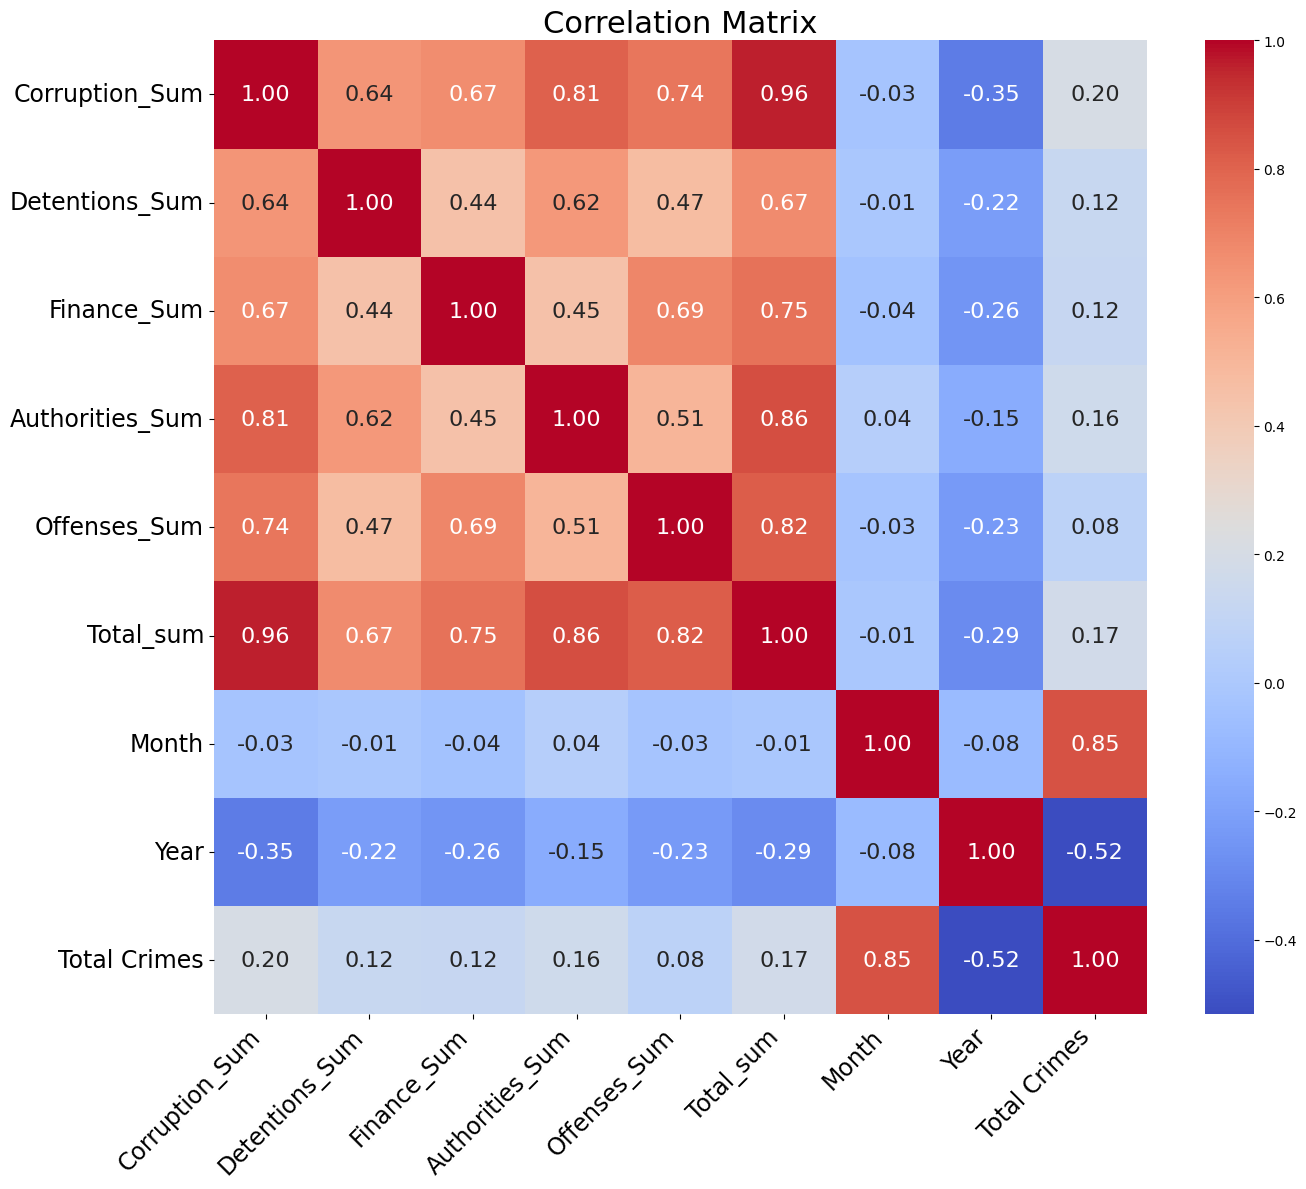

In [9]:
# Calculate correlation
correlation_matrix = df_agg.corr()

# Display correlation of the target variable with other features
target_corr = correlation_matrix["Total Crimes"].sort_values(ascending=False)
print("Correlation with the target variable:")
print(target_corr)

# Visualize the correlation matrix with larger labels and title
plt.figure(figsize=(14, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    annot_kws={"size": 16},
    xticklabels=correlation_matrix.columns,
    yticklabels=correlation_matrix.columns
)

plt.title("Correlation Matrix", fontsize=title_size)
plt.xticks(fontsize=labels_size, rotation=45, ha='right')
plt.yticks(fontsize=labels_size)
plt.tight_layout()
plt.show()

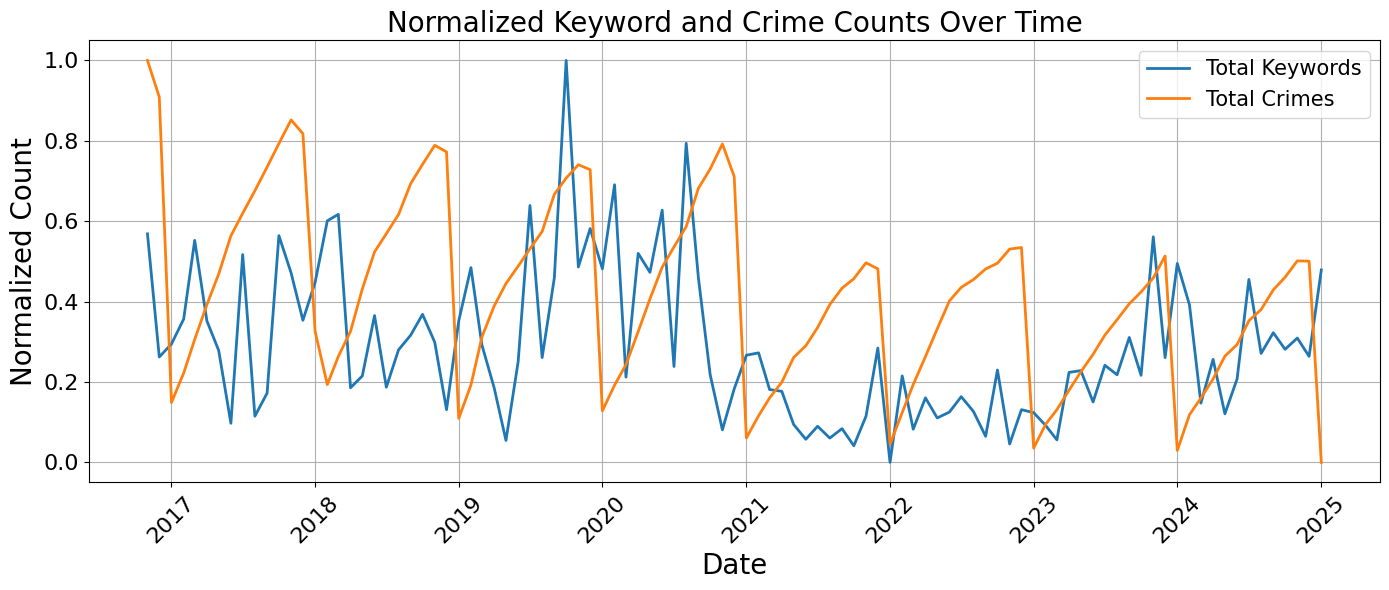

In [10]:
from sklearn.preprocessing import MinMaxScaler


# Plot settings
title_size = 20
labels_size = 20
ticks_size = 16
legend_size = 15

# Ensure datetime index
df_graph = pd.DataFrame()

df_graph["Date"] = pd.to_datetime(df["Date"])
df_graph.set_index("Date", inplace=True)

# Normalize values
keywords = df.drop(columns=["Total Crimes", "Date"]).sum(axis=1).values.reshape(-1, 1)
crimes = df["Total Crimes"].values.reshape(-1, 1)

scaler = MinMaxScaler()
keywords_scaled = scaler.fit_transform(keywords).flatten()
crimes_scaled = scaler.fit_transform(crimes).flatten()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df_graph.index, keywords_scaled, label="Total Keywords", linewidth=2)
plt.plot(df_graph.index, crimes_scaled, label="Total Crimes", linewidth=2)
plt.title("Normalized Keyword and Crime Counts Over Time", fontsize=title_size)
plt.xlabel("Date", fontsize=labels_size)
plt.ylabel("Normalized Count", fontsize=labels_size)
plt.xticks(rotation=45, fontsize=ticks_size)
plt.yticks(fontsize=ticks_size)
plt.legend(fontsize=legend_size)
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import grangercausalitytests

df_pearsonr = pd.DataFrame()
df_pearsonr["Total_Keywords"] = df_agg[['Corruption_Sum', 'Detentions_Sum', 'Finance_Sum', 'Authorities_Sum', 'Offenses_Sum']].sum(axis=1)
df_pearsonr["Total Crimes"] = df["Total Crimes"].values.copy()

# Calculate the Pearson correlation coefficient
corr, p_value = pearsonr(df_pearsonr["Total_Keywords"], df_pearsonr["Total Crimes"])

# Prepare data for Granger causality test (requires time lag, e.g., 1 month)
data = df_pearsonr[["Total Crimes", "Total_Keywords"]].dropna()

# Run Granger causality test with a lag of 1
test_result = grangercausalitytests(data, maxlag=1, verbose=True)

# Output the Pearson correlation and p-value
print(f"Pearson correlation: {corr:.3f}, p-value: {p_value:.3f}")

# Granger causality results are stored as a dictionary with lag keys (e.g., 1)
lag = 1  # or any lag you tested
result = test_result[lag]

# Access the test names and their results
f_test_stat = result[0]['ssr_ftest'][0]
f_test_pvalue = result[0]['ssr_ftest'][1]

print()
print(f"Granger Causality Test (lag={lag}):")
print(f"F-statistic: {f_test_stat:.4f}")
print(f"p-value: {f_test_pvalue:.4f}")



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.8952  , p=0.1718  , df_denom=95, df_num=1
ssr based chi2 test:   chi2=1.9551  , p=0.1620  , df=1
likelihood ratio test: chi2=1.9358  , p=0.1641  , df=1
parameter F test:         F=1.8952  , p=0.1718  , df_denom=95, df_num=1
Pearson correlation: 0.172, p-value: 0.088

Granger Causality Test (lag=1):
F-statistic: 1.8952
p-value: 0.1718


c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [12]:
# Splitting the original dataset into features (X) and target variable (y)
X_df = df.drop(columns=["Total Crimes", "Date"])
y_df = df["Total Crimes"]
X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(X_df, y_df, test_size=0.2, random_state=13)

# Splitting the aggregated dataset into features (X) and target variable (y)
X_agg = df_agg.drop(columns=["Total Crimes"])
y_agg = df_agg["Total Crimes"]
X_train_agg, X_test_agg, y_train_agg, y_test_agg = train_test_split(X_agg, y_agg, test_size=0.2, random_state=13)

In [13]:
# Function for training and evaluating a model
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{name}:")
    print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, R2: {r2:.2f}")
    print("-" * 30)

In [14]:
# List of models
models = [
    ("Linear Regression", LinearRegression()),
    ("Ridge Regression", Ridge(alpha=1.0)),
    ("Lasso Regression", Lasso(alpha=0.1)),
    ("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5)),
    ("Random Forest Regressor", RandomForestRegressor(n_estimators=100, random_state=13)),
    ("Gradient Boosting Regressor", GradientBoostingRegressor(n_estimators=100, random_state=13)),
    ("XGBoost Regressor", xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=13))
]

In [15]:
# Training and evaluation for df
print("Model evaluation on df:")
for name, model in models:
    evaluate_model(model, X_train_df, X_test_df, y_train_df, y_test_df, name)

# Training and evaluation for df_agg
print("Model evaluation on df_agg:")
for name, model in models:
    evaluate_model(model, X_train_agg, X_test_agg, y_train_agg, y_test_agg, name)

Model evaluation on df:
Linear Regression:
MAE: 554.20, MSE: 586670.13, R2: -0.47
------------------------------
Ridge Regression:
MAE: 553.98, MSE: 586135.83, R2: -0.47
------------------------------
Lasso Regression:
MAE: 554.17, MSE: 586606.47, R2: -0.47
------------------------------
ElasticNet:
MAE: 553.32, MSE: 584546.31, R2: -0.47
------------------------------
Random Forest Regressor:
MAE: 474.45, MSE: 379755.30, R2: 0.05
------------------------------
Gradient Boosting Regressor:
MAE: 541.85, MSE: 475861.61, R2: -0.19
------------------------------
XGBoost Regressor:
MAE: 530.06, MSE: 462366.49, R2: -0.16
------------------------------
Model evaluation on df_agg:
Linear Regression:
MAE: 150.74, MSE: 34387.88, R2: 0.91
------------------------------
Ridge Regression:
MAE: 150.65, MSE: 34342.52, R2: 0.91
------------------------------
Lasso Regression:
MAE: 150.73, MSE: 34381.42, R2: 0.91
------------------------------
ElasticNet:
MAE: 150.37, MSE: 34216.80, R2: 0.91
-----------

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.321e+05, tolerance: 2.933e+03
  model = cd_fast.enet_coordinate_descent(


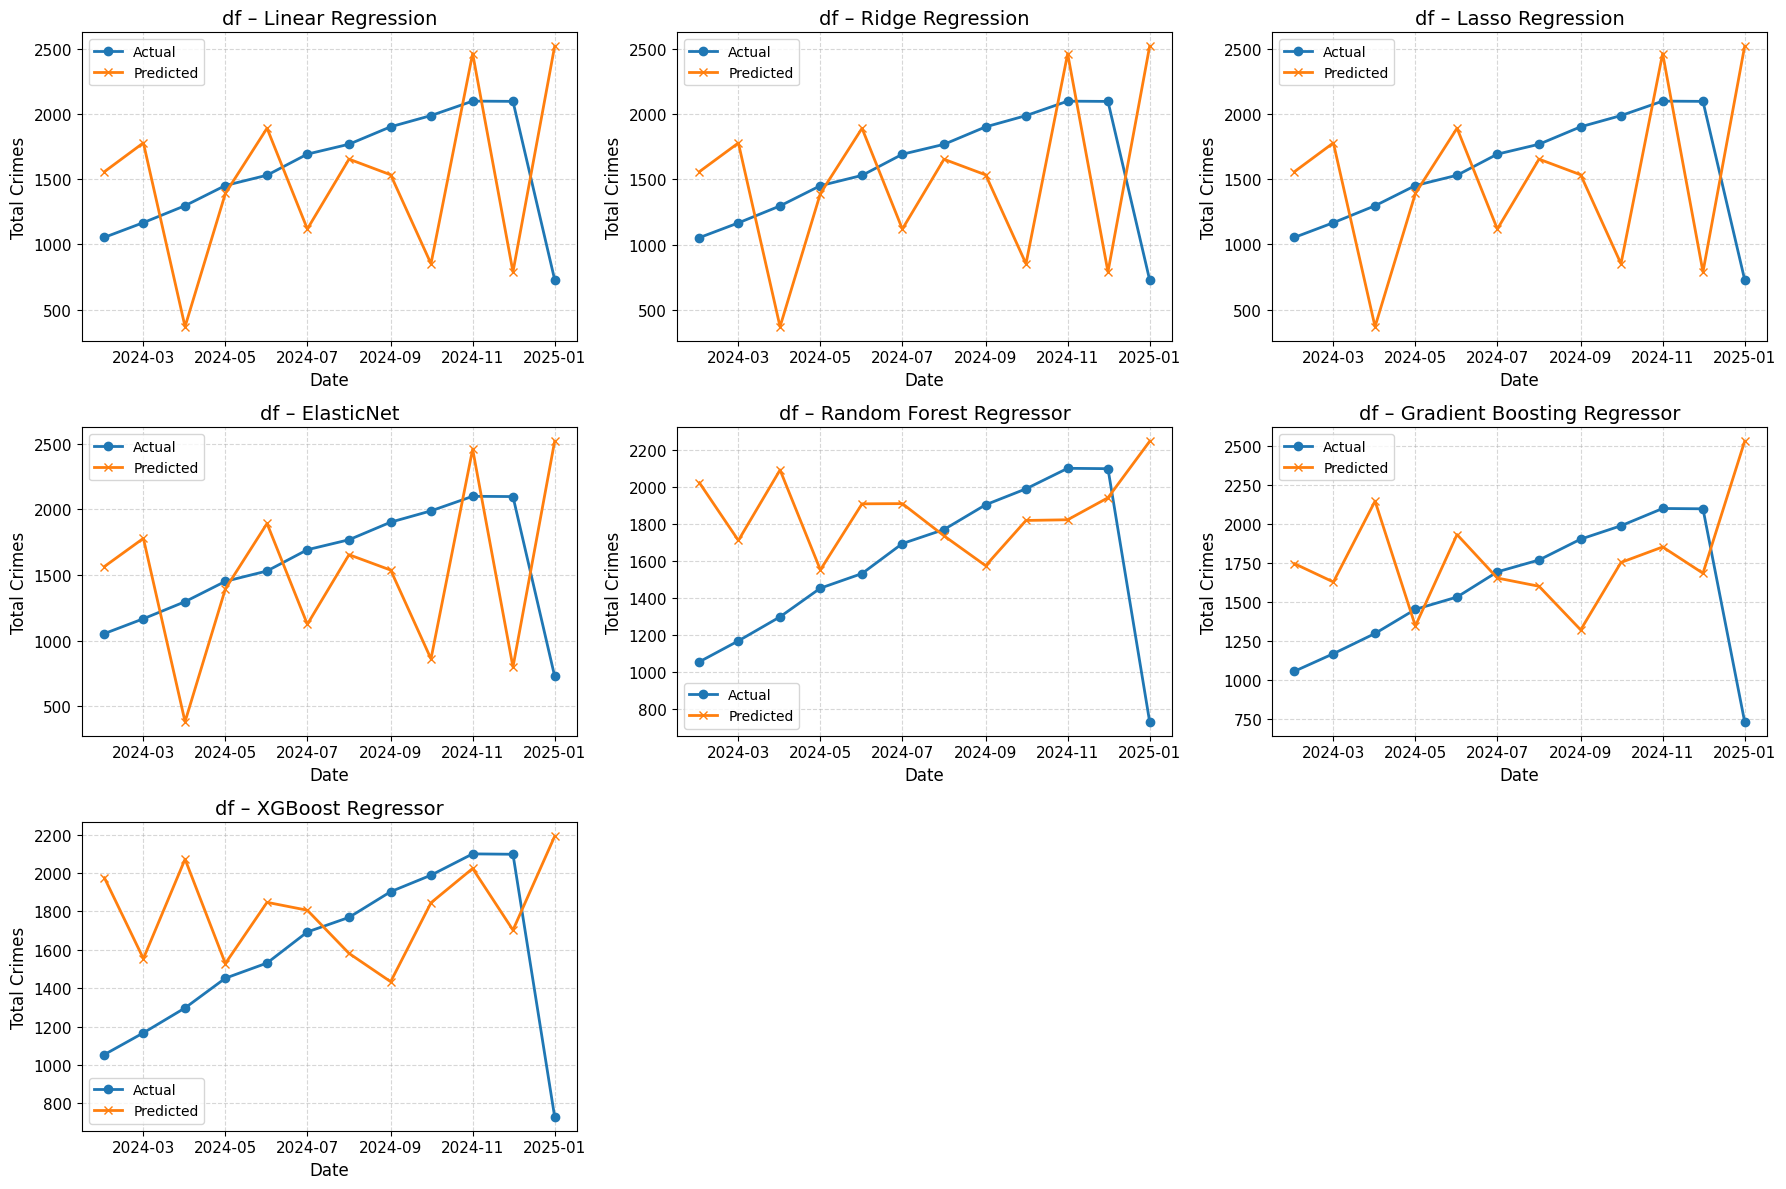

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.246e+04, tolerance: 3.385e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.488e+05, tolerance: 3.385e+03
  model = cd_fast.enet_coordinate_descent(


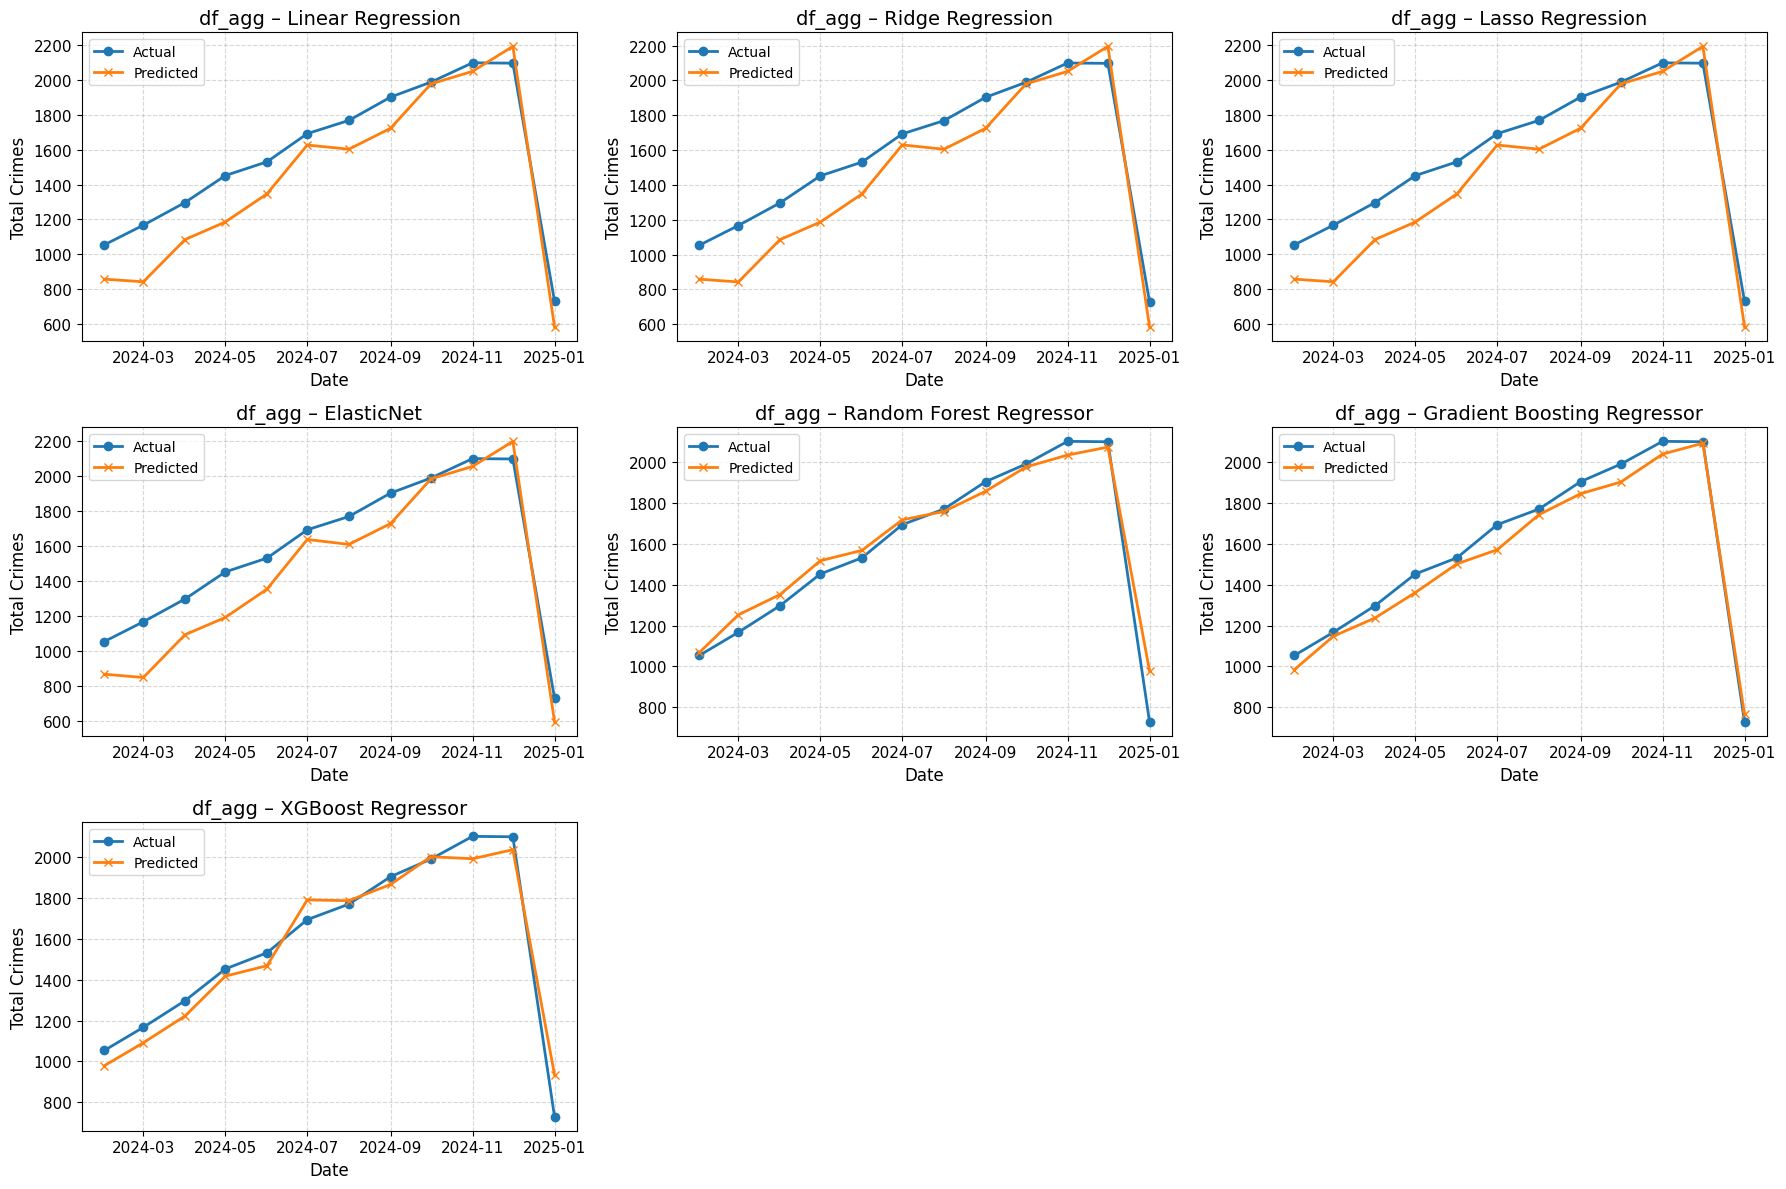

In [36]:
# df
X_df = df.drop(columns=["Total Crimes", "Date"])
y_df = df["Total Crimes"]

X_train_df = X_df.iloc[:-12]
X_test_df = X_df.iloc[-12:]
y_train_df = y_df.iloc[:-12]
y_test_df = y_df.iloc[-12:]
index_test_df = df.iloc[-12:]["Date"]  # Индексы для оси X

# df_agg
X_agg = df_agg.drop(columns=["Total Crimes"])
y_agg = df_agg["Total Crimes"]

X_train_agg = X_agg.iloc[:-12]
X_test_agg = X_agg.iloc[-12:]
y_train_agg = y_agg.iloc[:-12]
y_test_agg = y_agg.iloc[-12:]
index_test_agg = df.iloc[-12:]["Date"]  # Индексы для оси X

# Параметры оформления
label_fontsize = 12
title_fontsize = 14
tick_fontsize = 11
legend_fontsize = 10
line_width = 2

# Функция построения сетки графиков
def plot_predictions_grid(X_train, X_test, y_train, y_test, x_index, model_list, title_prefix):
    n_cols = 3
    n_rows = int(np.ceil(len(model_list) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = axes.flatten()
    
    for i, (name, model) in enumerate(model_list):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        ax = axes[i]
        ax.plot(x_index, y_test.values, label="Actual", marker='o', linewidth=line_width)
        ax.plot(x_index, y_pred, label="Predicted", marker='x', linewidth=line_width)
        
        ax.set_title(f"{title_prefix} – {name}", fontsize=title_fontsize)
        ax.set_xlabel("Date", fontsize=label_fontsize)
        ax.set_ylabel("Total Crimes", fontsize=label_fontsize)
        ax.tick_params(axis='both', labelsize=tick_fontsize)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=legend_fontsize)
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Визуализация
plot_predictions_grid(X_train_df, X_test_df, y_train_df, y_test_df, index_test_df, models, title_prefix="df")
plot_predictions_grid(X_train_agg, X_test_agg, y_train_agg, y_test_agg, index_test_agg, models, title_prefix="df_agg")


In [17]:
y_test_df.index

RangeIndex(start=87, stop=99, step=1)

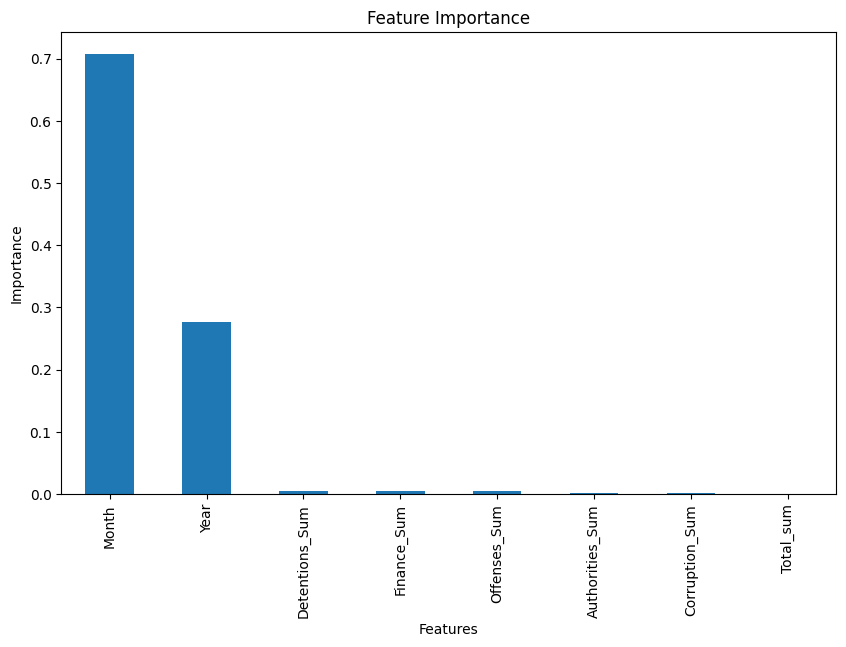

In [18]:
# Обучение модели XGBoost на агрегированных данных
xgb_model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42)
xgb_model.fit(X_train_agg, y_train_agg)

# Вычисление важности признаков
importance = pd.Series(xgb_model.feature_importances_, index=X_agg.columns)

# Сортировка и визуализация
importance.sort_values(ascending=False).plot(kind="bar", figsize=(10, 6), title="Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

## Year and month are the highest correlation with total crimes number. Thus, we use Time Series Analysis

In [19]:
df_agg.columns

Index(['Corruption_Sum', 'Detentions_Sum', 'Finance_Sum', 'Authorities_Sum',
       'Offenses_Sum', 'Total_sum', 'Month', 'Year', 'Total Crimes'],
      dtype='object')

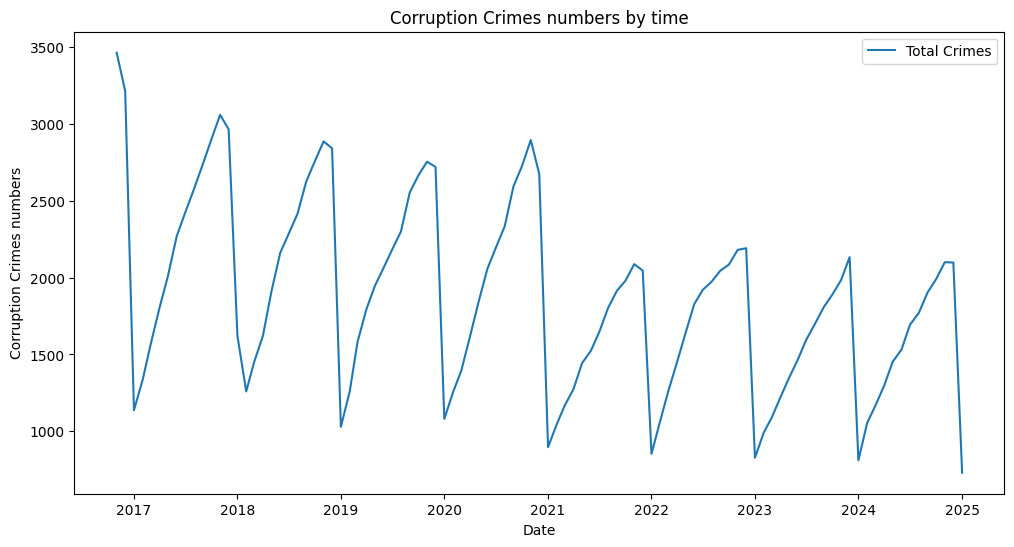

In [20]:
# Убедимся, что 'Date' является индексом
df_agg['Date'] = df['Date']
df_agg.set_index('Date', inplace=True)

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(df_agg.index, df_agg['Total Crimes'], label="Total Crimes")
plt.title("Corruption Crimes numbers by time")
plt.xlabel("Date")
plt.ylabel("Corruption Crimes numbers")
plt.legend()
plt.show()

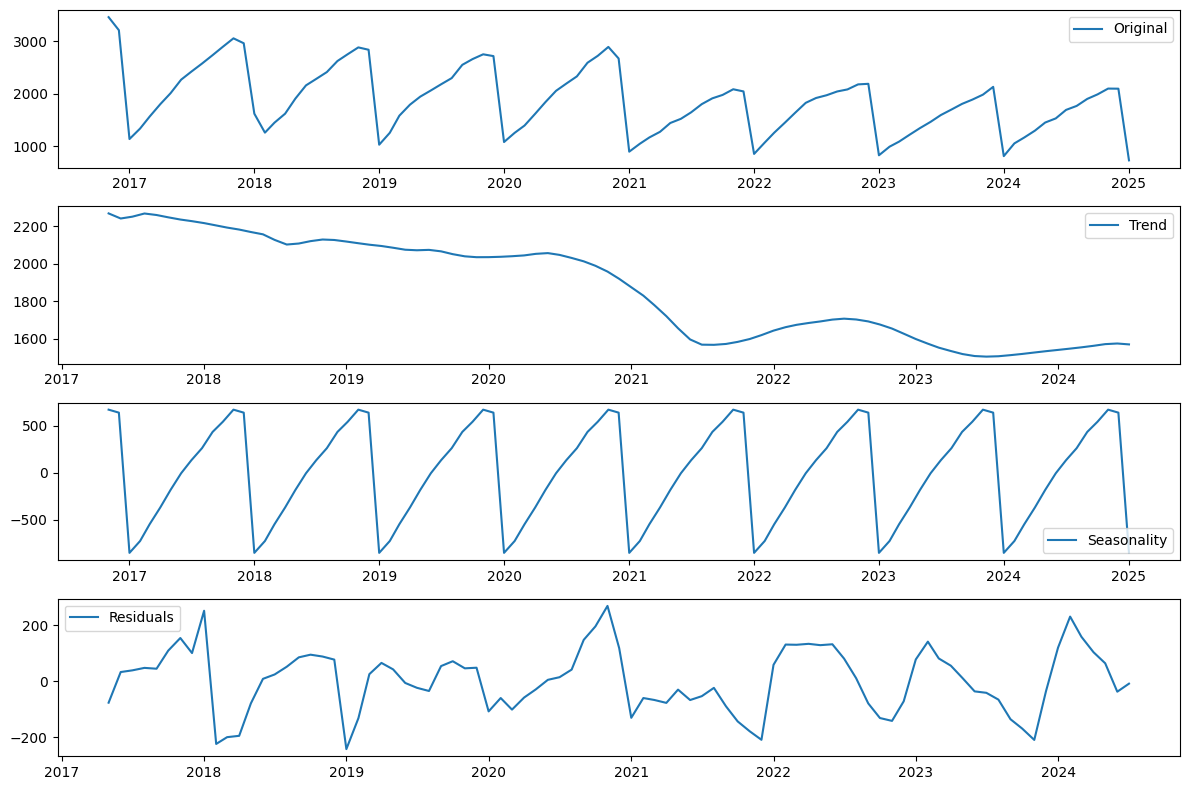

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decomposition of the time series
decomposition = seasonal_decompose(df_agg['Total Crimes'], model='additive', period=12)

# Visualization of components
plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(df_agg['Total Crimes'], label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


## Time Series Analysis with ARIMA

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


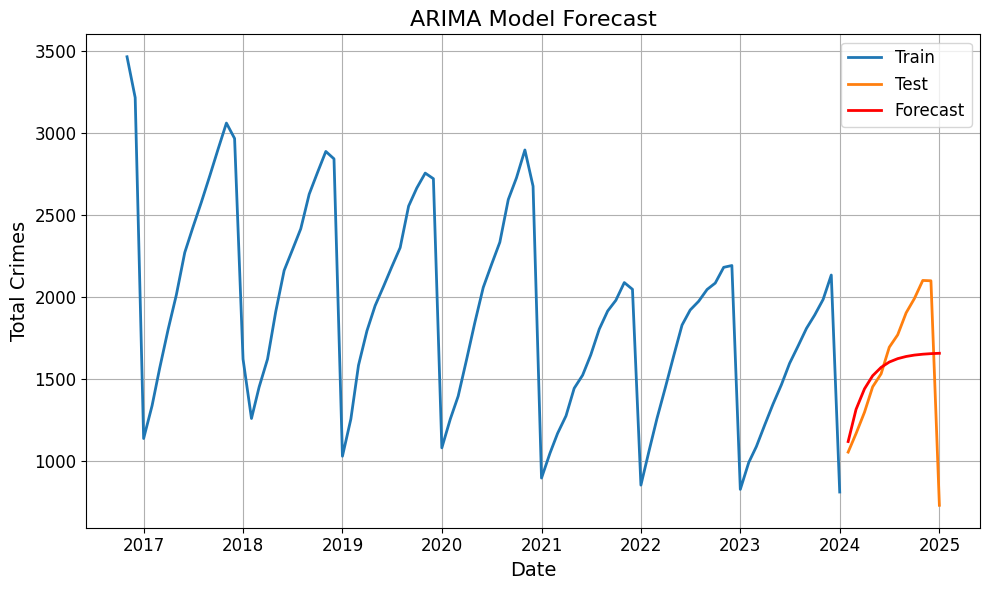

Mean Squared Error: 127302.91


In [22]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error


# Divide the data into training and test data
train = df_agg['Total Crimes'][:-12]
test = df_agg['Total Crimes'][-12:]

# Building the ARIMA model
model_arima = ARIMA(train, order=(1, 1, 1))  # ARIMA(p, d, q) parameters
model_fit_arima = model_arima.fit()

# Forecasting
forecast = model_fit_arima.forecast(steps=12)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train, label="Train", linewidth=2)
plt.plot(test, label="Test", linewidth=2)
plt.plot(test.index, forecast, label="Forecast", color='red', linewidth=2)
plt.title("ARIMA Model Forecast", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Total Crimes", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# MSE
mse = mean_squared_error(test, forecast)
print(f"Mean Squared Error: {mse:.2f}")


Что в целом можно сказать по графику?

Временной ряд явно сезонный (есть повторяющиеся колебания).
Модель ARIMA (1,1,1) плохо передает сезонность, так как прогноз (оранжевая линия) сглаженный.
Настоящие данные имеют более резкие спады и подъемы, а модель делает более мягкий прогноз.
Можно попробовать SARIMA (учитывает сезонность) или Prophet для более точного предсказания.

## Time Series Analysis with SARIMA

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\asanb\AppData\Local\Temp\ipykernel_10008\226040666.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Date': pd.date_range(start=train.index[-1] + pd.offsets.MonthEnd(1),


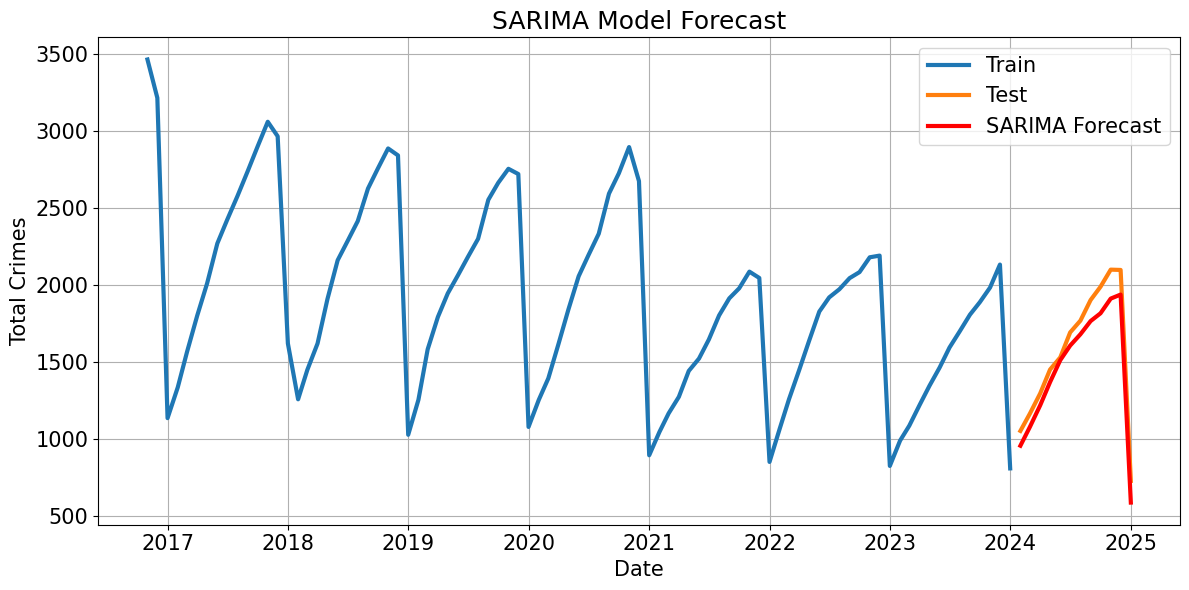

SARIMA Metrics:
MAE: 110.74
MSE: 14450.95
R2: 0.92

         Date  SARIMA Forecast
0  2024-01-31       958.082321
1  2024-02-29      1080.736042
2  2024-03-31      1219.920264
3  2024-04-30      1370.711688
4  2024-05-31      1513.083165
5  2024-06-30      1607.721513
6  2024-07-31      1680.665822
7  2024-08-31      1766.455586
8  2024-09-30      1816.879387
9  2024-10-31      1912.148114
10 2024-11-30      1938.379817
11 2024-12-31       589.331929


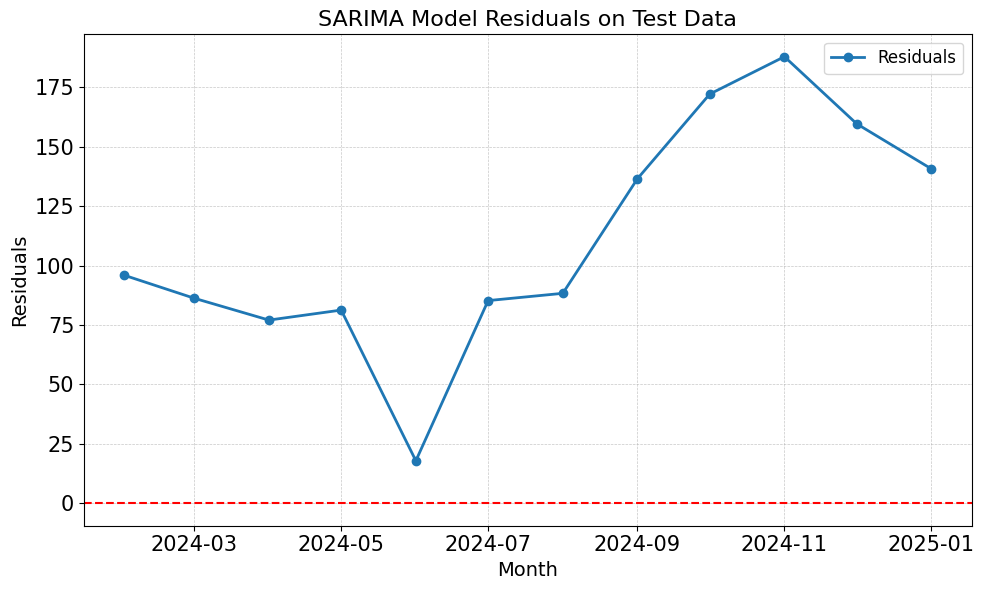

In [23]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA: set period=12
model_sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit_sarima = model_sarima.fit()
forecast_sarima = model_fit_sarima.forecast(steps=12)

# Create forecast df
df_sarima_forecast = pd.DataFrame({
    'Date': pd.date_range(start=train.index[-1] + pd.offsets.MonthEnd(1), 
                          periods=12, freq='M'),
    'SARIMA Forecast': forecast_sarima.values
})

# Plot forecast
linewidth = 3
label_size = 15
ticks_size = 15
title_size = 18
legend_size = 15

plt.figure(figsize=(12, 6))
plt.plot(train, label="Train", linewidth=linewidth)
plt.plot(test, label="Test", linewidth=linewidth)
plt.plot(test.index, forecast_sarima, label="SARIMA Forecast", color='red', linewidth=linewidth)
plt.title("SARIMA Model Forecast", fontsize=title_size)
plt.xlabel("Date", fontsize=label_size)
plt.ylabel("Total Crimes", fontsize=label_size)
plt.xticks(fontsize=ticks_size)
plt.yticks(fontsize=ticks_size)
plt.legend(fontsize=legend_size)
plt.grid(True)
plt.tight_layout()
plt.show()

# Metrics
mae = mean_absolute_error(test, forecast_sarima)
mse = mean_squared_error(test, forecast_sarima)
r2 = r2_score(test, forecast_sarima)

print(f"SARIMA Metrics:\nMAE: {mae:.2f}\nMSE: {mse:.2f}\nR2: {r2:.2f}")
print(f"\n{df_sarima_forecast}")

# Residuals Analysis
residuals = test - forecast_sarima

df_residuals = pd.DataFrame({
    'Actual': test,
    'Predicted': forecast_sarima,
    'Residuals': residuals
})
sarima_residuals = df_residuals['Residuals'].copy()
# Residuals Plot
plt.figure(figsize=(10, 6))
plt.plot(df_residuals.index, df_residuals['Residuals'], marker='o', linestyle='-', label='Residuals', linewidth=2)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.title('SARIMA Model Residuals on Test Data', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Residuals plot for SARIMA

### Когда кросс-валидация полезна в временных рядах?
- Проверка устойчивости модели — помогает понять, насколько модель устойчива при прогнозировании на разных временных отрезках.
- Выявление переобучения — если модель хорошо работает на одной выборке, но плохо на другой, значит, она может подстраиваться под шум, а не выявлять реальные закономерности.
- Оптимизация гиперпараметров — можно использовать Time Series CV для подбора параметров SARIMA или Prophet.
Какие методы кросс-валидации подходят для временных рядов?
Обычный k-fold не подходит, так как он перемешивает данные. 
Вместо него можно использовать:

1. Rolling Window Cross-Validation (скользящее окно)
- Берём окно длиной N месяцев, обучаемся на нём, предсказываем следующий шаг.
- Сдвигаем окно на 1 шаг и повторяем.
- Например, если N = 36, модель обучается на 3 годах данных, потом предсказывает следующий месяц.

2. Expanding Window Cross-Validation (расширяющееся окно)
- Начинаем с небольшого периода (например, 24 месяца).
- Постепенно добавляем новые месяцы в обучающий набор.
- Проверяем, улучшается ли модель с добавлением данных.

## Cross-validation for SARIMA

#### Rolling Window Cross-Validation

In [24]:
def rolling_cv_sarima(data, order, seasonal_order, window_size=60, horizon=12):
    errors = []
    
    for start in range(len(data) - window_size - horizon):
        train = data[start : start + window_size]
        test = data[start + window_size : start + window_size + horizon]
        
        # fit model
        model = SARIMAX(train, order=order, seasonal_order=seasonal_order)
        model_fit = model.fit(disp=False)
        
        # forecast
        forecast = model_fit.forecast(steps=horizon)
        
        # Metrics
        error = mean_squared_error(test, forecast)
        errors.append(error)
    
    return np.mean(errors), np.std(errors), errors

mean_mse, std_mse, rolling_errors = rolling_cv_sarima(df_agg['Total Crimes'], order=(1,1,1), seasonal_order=(1,1,1,12))
print(f"Mean MSE: {mean_mse:.2f}, Std: {std_mse:.2f}")

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\asanb\.pyenv\pyenv-wi

Mean MSE: 40084.32, Std: 46905.54


c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#### Expanding window cross-validation

In [25]:
initial_train_size = 36  # Начальный размер обучающего окна
test_size = 12  # Размер тестового окна
y = df_agg["Total Crimes"]
expanding_errors = []

for train_end in range(initial_train_size, len(y) - test_size + 1):
    train_data = y.iloc[:train_end]  # Обучающая выборка расширяется на каждом шаге
    test_data = y.iloc[train_end:train_end + test_size]  # Тестовая выборка фиксированного размера
    
    # Обучаем модель на train_data
    model = SARIMAX(train_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    model_fit = model.fit(disp=False)
    
    # Делаем предсказание
    predictions = model_fit.forecast(steps=test_size)
    
    # Оцениваем MSE
    mse = mean_squared_error(test_data, predictions)
    expanding_errors.append(mse)

# Вычисляем средний и стандартное отклонение ошибки
mean_mse = np.mean(expanding_errors)
std_mse = np.std(expanding_errors)

print(f"Expanding Window CV - Mean MSE: {mean_mse:.2f}, Std: {std_mse:.2f}")

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood op

Expanding Window CV - Mean MSE: 60817.13, Std: 51987.95


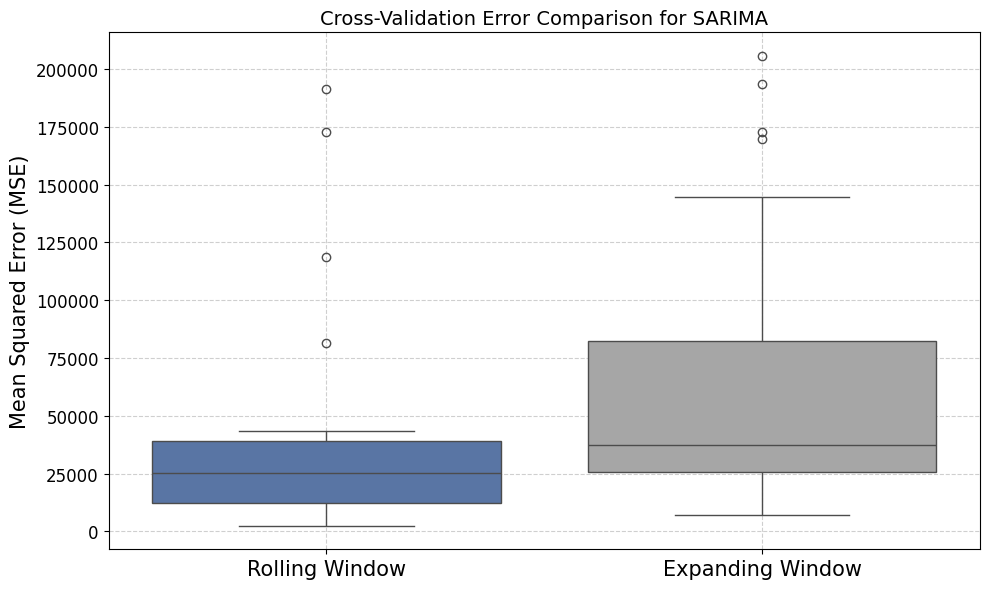

In [26]:
# Custom academic colors
colors = ['#4C72B0', '#A6A6A6']  # Blue and Gray

# Create the boxplot with correct labels
plt.figure(figsize=(10, 6))
sns.boxplot(data=[rolling_errors, expanding_errors], palette=colors)
plt.xticks([0, 1], ['Rolling Window', 'Expanding Window'], fontsize=15)
plt.yticks(fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=15)
plt.title("Cross-Validation Error Comparison for SARIMA", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Prophet

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
17:16:53 - cmdstanpy - INFO - Chain [1] start processing
17:16:54 - cmdstanpy - INFO - Chain [1] done processing


Prophet Metrics:
MAE: 209.83
MSE: 54499.43
R2: 0.69


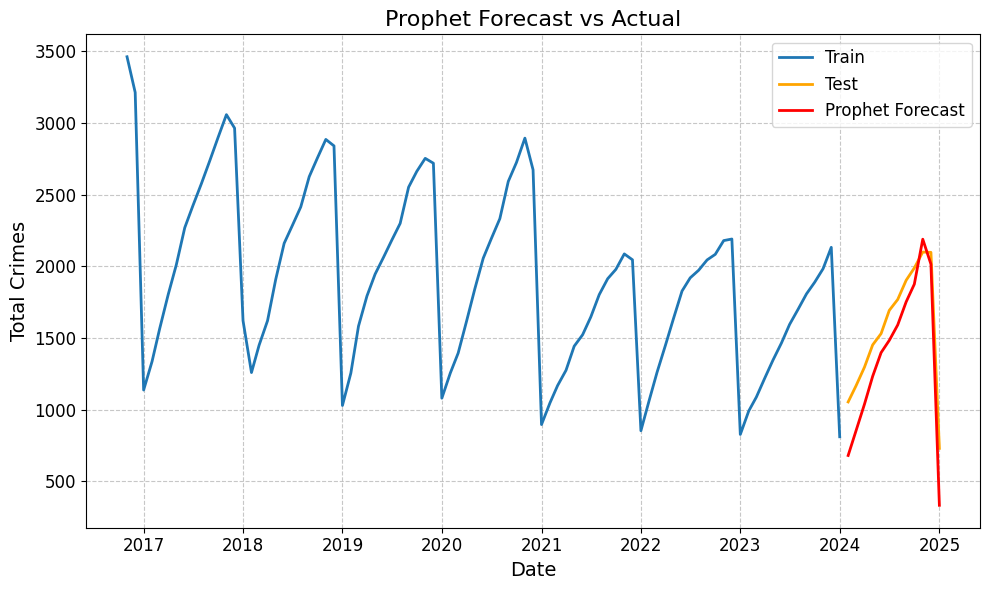

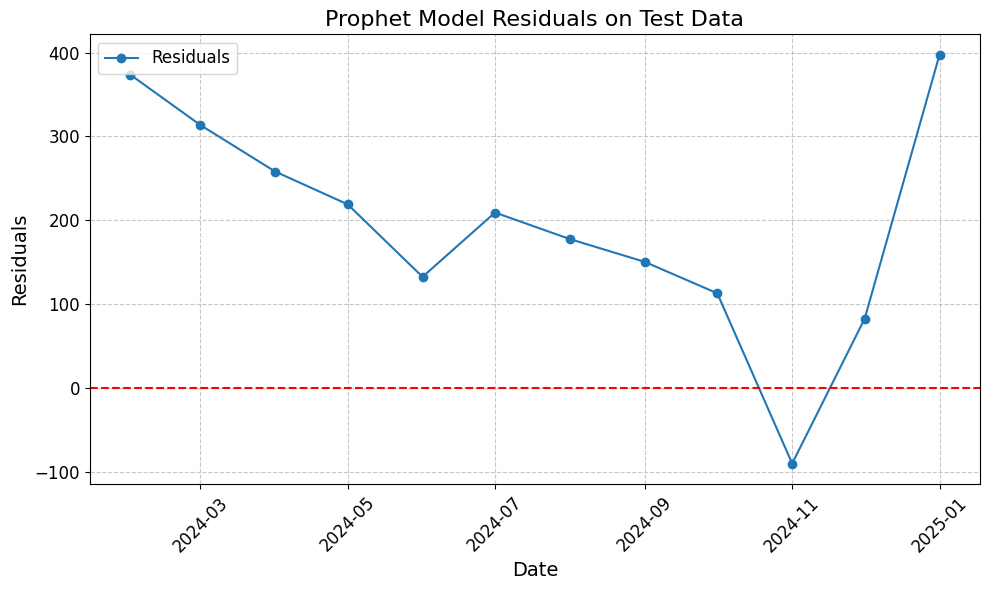

In [27]:
from prophet import Prophet

# Подготовка данных
prophet_df = df_agg.reset_index()[['Date', 'Total Crimes']].copy()
prophet_df.columns = ['ds', 'y']

# Разделим данные (аналогично SARIMA)
train_df = prophet_df.iloc[:-12]
test_df = prophet_df.iloc[-12:]

# Инициализация и обучение модели
model_prophet = Prophet()
model_prophet.fit(train_df)

# Создание будущих дат (только для тестового периода)
future = model_prophet.make_future_dataframe(periods=12, freq='MS')
forecast = model_prophet.predict(future)

# Получение прогноза на период теста
forecast_test = forecast.set_index('ds').loc[test_df['ds']]

# Остатки
residuals = test_df.set_index('ds')['y'] - forecast_test['yhat']

# Вычисление метрик
mae = mean_absolute_error(test_df['y'], forecast_test['yhat'])
mse = mean_squared_error(test_df['y'], forecast_test['yhat'])
r2 = r2_score(test_df['y'], forecast_test['yhat'])

print(f"Prophet Metrics:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2: {r2:.2f}")

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(train_df['ds'], train_df['y'], label='Train', linewidth=2)
plt.plot(test_df['ds'], test_df['y'], label='Test', linewidth=2, color='orange')
plt.plot(forecast_test.index, forecast_test['yhat'], label='Prophet Forecast', color='red', linewidth=2)
plt.title("Prophet Forecast vs Actual", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Total Crimes", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Построение графика остатков
plt.figure(figsize=(10, 6))
plt.plot(residuals.index, residuals, marker='o', linestyle='-', label='Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.title("Prophet Model Residuals on Test Data", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Residuals", fontsize=14)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Cross-validation for Prophet

In [28]:
from prophet.diagnostics import cross_validation, performance_metrics

# **Cross-Validation в Prophet**
df_cv = cross_validation(
    model_prophet,
    initial="1825 days",  # ~60 months
    period="365 days",    # ~12 months step
    horizon="365 days"    # Forecast horizon ~12 months
)

# Perfomance test
df_performance = performance_metrics(df_cv)
print(df_performance[["horizon", "mse", "rmse", "mae", "mape"]])

  0%|          | 0/2 [00:00<?, ?it/s]17:16:54 - cmdstanpy - INFO - Chain [1] start processing
17:16:54 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 1/2 [00:00<00:00,  2.61it/s]17:16:54 - cmdstanpy - INFO - Chain [1] start processing
17:16:55 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 2/2 [00:00<00:00,  2.58it/s]

    horizon            mse        rmse         mae      mape
0   31 days  189138.349096  434.900390  402.232632  0.384990
1   59 days  177074.739785  420.802495  371.689848  0.306112
2   90 days  187627.322107  433.159696  361.344324  0.257267
3  120 days  184982.242010  430.095620  324.268380  0.200729
4  151 days  203724.683966  451.358709  333.977581  0.184759
5  181 days  188901.278357  434.627747  328.954981  0.173713
6  212 days  150563.879149  388.025617  307.891222  0.158972
7  243 days  102478.001425  320.121854  293.612082  0.148898
8  273 days   81106.658321  284.792307  270.613082  0.134357
9  304 days   68425.444119  261.582576  231.370205  0.108610
10 334 days  103169.213110  321.199647  240.566242  0.109970
11 365 days  281235.065425  530.316005  463.150695  0.562480


# SARIMA и Prophet в stacked hybrid

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
17:16:56 - cmdstanpy - INFO - Chain [1] start processing
17:16:56 - cmdstanpy - INFO - Chain [1] done processing


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     782.6
Date:                Sun, 13 Apr 2025   Prob (F-statistic):           1.03e-11
Time:                        17:16:56   Log-Likelihood:                -65.022
No. Observations:                  13   AIC:                             136.0
Df Residuals:                      10   BIC:                             137.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        201.7376     73.114      2.759      0.0

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=13 observations were given.
  return hypotest_fun_in(*args, **kwds)


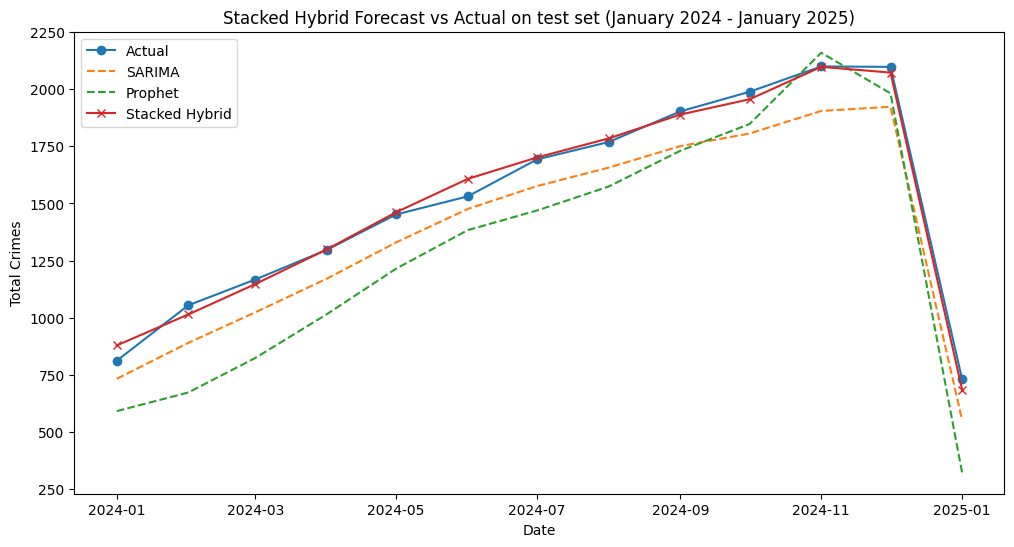

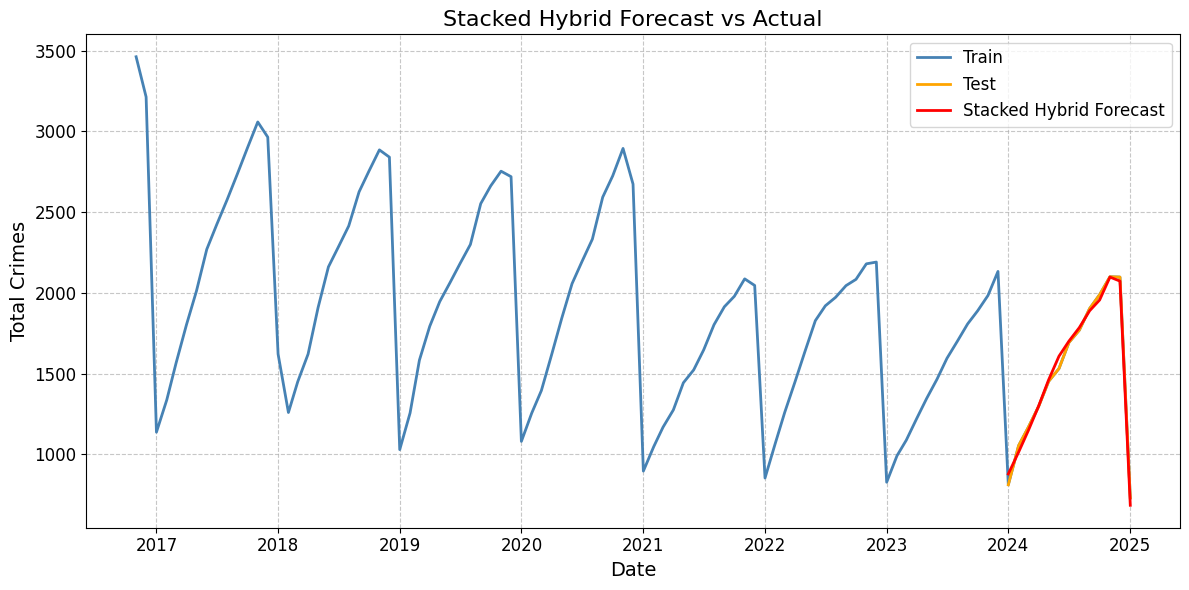

In [29]:
import statsmodels.api as sm

# Предположим, что у нас есть DataFrame df_sh с колонками 'Date' и 'Total Crimes'
# Преобразуем дату и отсортируем данные
df_sh = df_agg[["Total Crimes"]].copy()

# Разделим данные:
# Допустим, тренировка – до конца 2023, тест – 2024 (12 месяцев)
train = df_sh.loc[:'2023-12-31']['Total Crimes']
test = df_sh.loc['2024-01-01':'2025-01-31']['Total Crimes']

### 1. Обучение SARIMA и прогноз на тестовый период

model_sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit_sarima = model_sarima.fit(disp=False)
sarima_forecast = model_fit_sarima.get_forecast(steps=len(test))
sarima_pred = sarima_forecast.predicted_mean

### 2. Обучение Prophet и прогноз на тестовый период

# Подготавливаем данные для Prophet (требуется DataFrame с колонками ds и y)
prophet_train = train.reset_index()
prophet_train.columns = ['ds', 'y']
model_prophet = Prophet()
model_prophet.fit(prophet_train)

# Создаем будущее на длину тестового периода (используем, например, 'MS' для начала месяца, если тест имеет даты начала месяца)
future = model_prophet.make_future_dataframe(periods=len(test), freq='MS')
forecast_prophet = model_prophet.predict(future)

# Устанавливаем индекс 'ds' и переиндексируем по тестовому индексу, используя ближайшие значения
prophet_pred = forecast_prophet.set_index('ds')['yhat']
prophet_pred = prophet_pred.reindex(test.index, method='nearest')

### 3. Объединение прогнозов базовых моделей

df_stack = pd.DataFrame({
    'Actual': test,
    'SARIMA': sarima_pred,
    'Prophet': prophet_pred
})

### 4. Обучение мета-модели (stacking) на прогнозах базовых моделей

# Используем прогнозы SARIMA и Prophet как признаки
X_stack = df_stack[['SARIMA', 'Prophet']].values
y_stack = df_stack['Actual'].values

meta_model = LinearRegression()
meta_model.fit(X_stack, y_stack)
stacked_pred = meta_model.predict(X_stack)

# OLS Summary
X_ols = sm.add_constant(X_stack)
ols_model = sm.OLS(y_stack, X_ols).fit()
print(ols_model.summary())

### 5. Вычисление метрик и визуализация

mae = mean_absolute_error(y_stack, stacked_pred)
mse = mean_squared_error(y_stack, stacked_pred)
r2 = r2_score(y_stack, stacked_pred)

print("Stacked Hybrid Model Metrics:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2: {r2:.2f}")

# Создаем DataFrame с итоговыми прогнозами
df_stack['Stacked'] = stacked_pred

# Построим график: фактические значения vs. прогнозы базовых моделей и итоговый стек
plt.figure(figsize=(12, 6))
plt.plot(df_stack.index, df_stack['Actual'], label='Actual', marker='o')
plt.plot(df_stack.index, df_stack['SARIMA'], label='SARIMA', linestyle='--')
plt.plot(df_stack.index, df_stack['Prophet'], label='Prophet', linestyle='--')
plt.plot(df_stack.index, df_stack['Stacked'], label='Stacked Hybrid', linestyle='-', marker='x')
plt.xlabel('Date')
plt.ylabel('Total Crimes')
plt.title('Stacked Hybrid Forecast vs Actual on test set (January 2024 - January 2025)')
plt.legend()
plt.show()

# Full plot
plt.figure(figsize=(12, 6))

# Полный временной ряд
plt.plot(df_sh.index, df_sh["Total Crimes"], label='Train', color='steelblue', linewidth=2)

# Тестовая часть
plt.plot(df_stack.index, df_stack['Actual'], label='Test', color='orange', linewidth=2)

# Итоговый прогноз стека
plt.plot(df_stack.index, df_stack['Stacked'], label='Stacked Hybrid Forecast', color='red', linewidth=2)

# Оформление
plt.title("Stacked Hybrid Forecast vs Actual", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Total Crimes", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Судя по графику и метрикам:

Высокий 𝑅 2 (0.99)
Это говорит о том, что объединённая (stacked) модель очень хорошо объясняет вариацию данных в тестовом периоде. Значение 0.99 означает, что около 99% разброса фактических значений учтено моделью.

Низкий MAE (25.67)
Средняя абсолютная ошибка около 25.67 значит, что в среднем на всём тестовом промежутке прогноз отклоняется от фактических значений примерно на 26 единиц. С учётом того, что уровень преступлений превышает 1000-2000 в ряде точек, такая ошибка относительно невелика.

MSE (1123.24)
Среднеквадратичная ошибка чуть выше тысячи. Поскольку MSE сильнее «штрафует» крупные промахи, чем MAE, это значение говорит, что крупных «выбросов» в ошибках немного, но они могут чуть повышать MSE.

Визуальный анализ графика

Stacked Hybrid (красная линия) идёт очень близко к фактическим точкам (синим), особенно ближе к концу ряда.

SARIMA (оранжевая) и Prophet (зелёная) в данном случае дают прогнозы, которые заметно ниже фактических в конце периода, но модель SARIMA ближе к данным в начале периода.

Благодаря мета-модели (линейная регрессия в стэкинге), итоговый прогноз (Stacked) корректируется и идёт близко к фактическим значениям.

Итог
Stacked Hybrid сумел объединить преимущества SARIMA и Prophet, дав точный итоговый прогноз.

Низкие ошибки и высокий R2 подтверждают, что данный подход хорошо подходит для данных тестового периода.

Если нужно долгосрочное прогнозирование (выходящее за пределы тестовых дат), всё равно стоит следить за тем, чтобы в данных не происходило резких изменений, которые ни SARIMA, ни Prophet не видели.

В целом, эти результаты указывают, что гибридная модель, комбинирующая тренд и сезонность (SARIMA, Prophet), способна достичь высокой точности на имеющемся тестовом отрезке.

## Analysis of Residuals in stacked hybrid

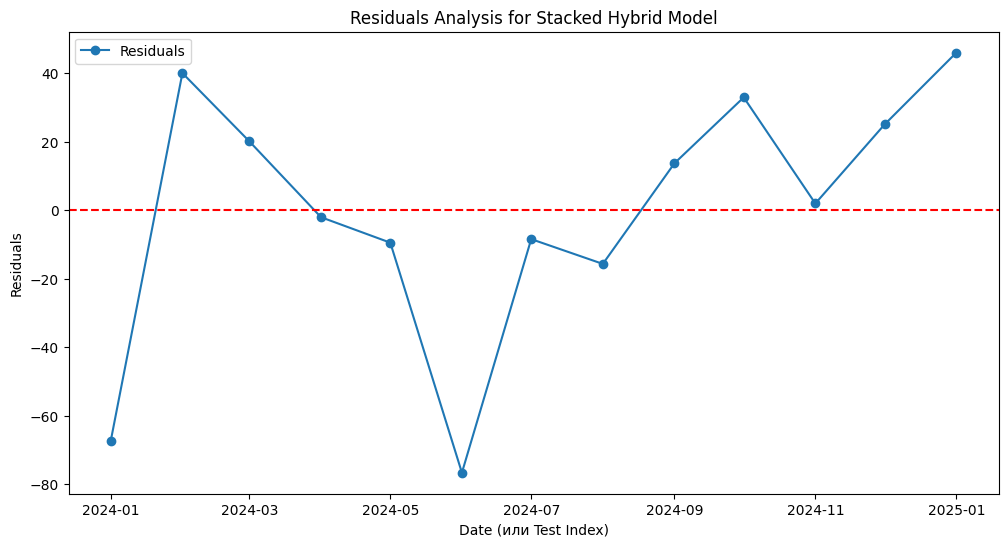

In [30]:
# Предположим, что у вас уже есть DataFrame df_stack с колонками 'Actual' и 'Stacked'
# Вычисляем остатки
df_stack['Residuals'] = df_stack['Actual'] - df_stack['Stacked']

# Построим график остатков по времени (или по индексам, если это последовательность тестовых наблюдений)
plt.figure(figsize=(12, 6))
plt.plot(df_stack.index, df_stack['Residuals'], marker='o', linestyle='-', label='Residuals')
plt.axhline(0, color='red', linestyle='--')  # Линия y=0
plt.xlabel('Date (или Test Index)')
plt.ylabel('Residuals')
plt.title('Residuals Analysis for Stacked Hybrid Model')
plt.legend()
plt.show()

## CV for stacked hybrid

In [31]:
# Параметры кросс-валидации
test_horizon = 12  # Сколько месяцев в тестовом отрезке
n_folds = 3        # Сколько "складок" (folds) сделаем

# Вычислим, сколько данных всего
n_total = len(df_sh)

# Подготовим списки для метрик
mae_list, mse_list, r2_list = [], [], []
stacked_cv_residuals_list = []
dates = df_sh.index

# Функция для обучения базовых моделей и построения stacked hybrid
def train_stacked_model(train_data, test_data):
    """Возвращает предсказания stacked-модели на тесте и фактические значения."""
    # 1) SARIMA
    model_sarima = SARIMAX(train_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    model_fit_sarima = model_sarima.fit(disp=False)
    sarima_forecast = model_fit_sarima.get_forecast(steps=len(test_data))
    sarima_pred = sarima_forecast.predicted_mean

    # 2) Prophet
    prophet_train = train_data.reset_index()
    prophet_train.columns = ['ds', 'y']
    model_prophet = Prophet()
    model_prophet.fit(prophet_train)
    
    future = model_prophet.make_future_dataframe(periods=len(test_data), freq='MS')
    forecast_prophet = model_prophet.predict(future)
    
    # Переиндексируем по датам test_data
    prophet_pred = forecast_prophet.set_index('ds')['yhat']
    # Если индексы теста – первое число месяца, а Prophet выдаёт конец месяца,
    # можно reindex(..., method='nearest'), чтобы сопоставить даты
    prophet_pred = prophet_pred.reindex(test_data.index, method='nearest')

    # 3) Обучение stacked-модели
    df_stack = pd.DataFrame({
        'Actual': test_data,
        'SARIMA': sarima_pred,
        'Prophet': prophet_pred
    })

    X_stack = df_stack[['SARIMA', 'Prophet']].values
    y_stack = df_stack['Actual'].values
    
    meta_model = LinearRegression()
    meta_model.fit(X_stack, y_stack)
    stacked_pred = meta_model.predict(X_stack)

    return y_stack, stacked_pred  # Возвращаем фактические значения и прогноз стэка

# Главный цикл кросс-валидации
# Определим начальный размер train, затем будем расширять
# Например, разобьём оставшиеся данные на n_folds отрезков для теста
# Пример: если у нас много данных, можно делать более гибкую логику
start_train_size = len(df_sh) - (n_folds * test_horizon)
# В реальности стоит убедиться, что start_train_size > 0

for fold in range(n_folds):
    # Конец train = start_train_size + fold * test_horizon
    end_train_idx = start_train_size + fold * test_horizon
    
    # Тренировочный отрезок
    train_data = df_sh.iloc[:end_train_idx]['Total Crimes']
    
    # Тестовый отрезок
    test_data = df_sh.iloc[end_train_idx : end_train_idx + test_horizon]['Total Crimes']
    
    if len(test_data) < test_horizon:
        # Если данных не хватает, выходим
        break
    
    # Обучаем stacked-модель на train_data, получаем прогноз на test_data
    y_true, y_pred = train_stacked_model(train_data, test_data)
    
    # Считаем метрики
    mae_fold = mean_absolute_error(y_true, y_pred)
    mse_fold = mean_squared_error(y_true, y_pred)
    r2_fold = r2_score(y_true, y_pred)
    
    # stacked hybrid cv residuals
    residuals = y_true - y_pred
    stacked_cv_residuals_list.extend(residuals.tolist())

    mae_list.append(mae_fold)
    mse_list.append(mse_fold)
    r2_list.append(r2_fold)

    print(f"Fold {fold + 1}: MAE={mae_fold:.2f}, MSE={mse_fold:.2f}, R²={r2_fold:.2f}")

# После цикла усредняем метрики
mean_mae = np.mean(mae_list)
mean_mse = np.mean(mse_list)
mean_r2  = np.mean(r2_list)

print("=== Cross-Validation Results ===")
print(f"Average MAE: {mean_mae:.2f}")
print(f"Average MSE: {mean_mse:.2f}")
print(f"Average R2 : {mean_r2:.2f}")

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
17:16:56 - cmdstanpy - INFO - Chain [1] start processing
17:16:57 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so infer

Fold 1: MAE=54.41, MSE=3950.71, R²=0.98


17:16:57 - cmdstanpy - INFO - Chain [1] start processing
17:16:58 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Fold 2: MAE=37.46, MSE=3124.74, R²=0.98


17:16:58 - cmdstanpy - INFO - Chain [1] start processing
17:16:58 - cmdstanpy - INFO - Chain [1] done processing


Fold 3: MAE=22.46, MSE=870.39, R²=1.00
=== Cross-Validation Results ===
Average MAE: 38.11
Average MSE: 2648.61
Average R2 : 0.99


In [32]:
len(stacked_cv_residuals_list) / 3

12.0

## Forecast numbers of 25/26 years

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
17:16:59 - cmdstanpy - INFO - Chain [1] start processing
17:16:59 - cmdstanpy - INFO - Chain [1] done processing


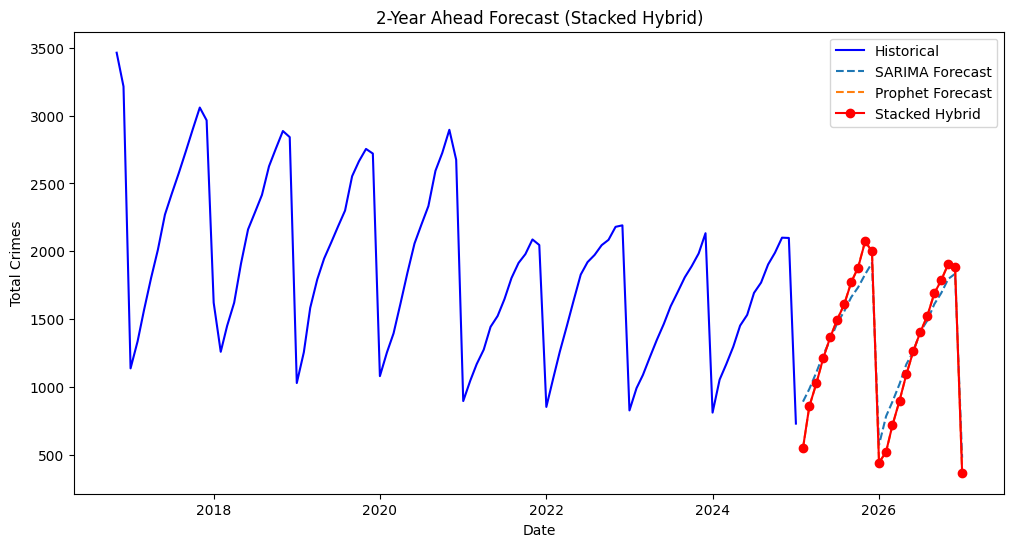

In [33]:
y = df_sh['Total Crimes']

# Обучим SARIMA и Prophet на всех исторических данных (до последней даты в df_sh)
train_data = y.copy()

### 2) Обучение SARIMA на всём датасете
sarima_model = SARIMAX(train_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_fit = sarima_model.fit(disp=False)

### 3) Обучение Prophet на всём датасете
prophet_train = train_data.reset_index()
prophet_train.columns = ['ds', 'y']
model_prophet = Prophet()
model_prophet.fit(prophet_train)

# 4) Получение "исторических" прогнозов для обучения мета-модели
#    Мы хотим, чтобы и SARIMA, и Prophet выдавали прогноз на те даты, которые уже есть в train_data,
#    чтобы потом сравнить с фактическими значениями и обучить линейную регрессию.

# SARIMA in-sample predictions
sarima_in_sample = sarima_fit.fittedvalues  # или model_fit.get_prediction(start=..., end=...)

# Prophet in-sample predictions
# Для Prophet сделаем predict на весь исторический период (train_data)
future_train = model_prophet.make_future_dataframe(periods=0, freq='MS') 
# Указываем частоту 'MS', если данные помесячные (Month Start)
# (Если у вас daily, тогда freq='D', и т.д.)

prophet_pred_full = model_prophet.predict(future_train)
prophet_pred_full = prophet_pred_full.set_index('ds')['yhat']

# Теперь нам нужно совместить SARIMA in-sample и Prophet in-sample на совпадающих датах
df_in_sample = pd.DataFrame({
    'Actual': train_data,  # фактические значения
    'SARIMA': sarima_in_sample,
    'Prophet': prophet_pred_full
})

# Удалим строки, где есть NaN (в начале ряда SARIMA может быть NaN)
df_in_sample.dropna(inplace=True)

# 5) Обучение мета-модели (LinearRegression)
X_stack = df_in_sample[['SARIMA', 'Prophet']]
y_stack = df_in_sample['Actual']

meta_model = LinearRegression()
meta_model.fit(X_stack, y_stack)

# 6) Прогноз на 2 года вперёд (24 месяца)
# Определим последнюю дату в исторических данных
last_date = df_sh.index[-1]
# Сформируем даты будущего периода (24 месяца вперёд)
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthEnd(1),
    periods=24,
    freq='MS'
)

### 6a) Прогноз SARIMA на 24 месяца вперёд
sarima_forecast = sarima_fit.get_forecast(steps=24)
sarima_future_pred = sarima_forecast.predicted_mean
sarima_future_pred.index = future_dates  # переименуем индекс под наши будущие даты

### 6b) Прогноз Prophet на 24 месяца вперёд
future_df = model_prophet.make_future_dataframe(periods=24, freq='MS')
prophet_forecast = model_prophet.predict(future_df)
prophet_forecast = prophet_forecast.set_index('ds')['yhat'].iloc[-24:]  # последние 24 строки
prophet_forecast.index = future_dates  # переименуем индекс

### 6c) Формируем DataFrame с базовыми прогнозами
df_future = pd.DataFrame({
    'SARIMA': sarima_future_pred,
    'Prophet': prophet_forecast
}, index=future_dates)

# 7) Применяем мета-модель к будущим прогнозам
X_future = df_future[['SARIMA', 'Prophet']]
stacked_pred = meta_model.predict(X_future)

df_future['Stacked'] = stacked_pred

# 8) Визуализация итогового прогноза
plt.figure(figsize=(12, 6))

# Построим исторические данные
plt.plot(y.index, y.values, label='Historical', color='blue')

# Построим будущие прогнозы
plt.plot(df_future.index, df_future['SARIMA'], '--', label='SARIMA Forecast')
plt.plot(df_future.index, df_future['Prophet'], '--', label='Prophet Forecast')
plt.plot(df_future.index, df_future['Stacked'], '-o', label='Stacked Hybrid', color='red')

plt.title('2-Year Ahead Forecast (Stacked Hybrid)')
plt.xlabel('Date')
plt.ylabel('Total Crimes')
plt.legend()
plt.show()

In [34]:
df_future

,SARIMA,Prophet,Stacked
2025-02-01,891.593610,545.626049,549.296274
2025-03-01,985.271913,856.967547,857.574041
2025-04-01,1108.551810,1027.448570,1027.590475
2025-05-01,1237.972298,1212.699275,1212.259841
2025-06-01,1346.678524,1368.047610,1367.123644
2025-07-01,1469.984311,1495.030136,1494.290609
2025-08-01,1556.473238,1608.850464,1607.871230
2025-09-01,1661.546837,1772.704361,1771.052558
2025-10-01,1733.568416,1881.010923,1878.957836
2025-11-01,1829.951580,2075.519690,2072.190506


----------------------------------